<a href="https://colab.research.google.com/github/Ritapaz/exemplo-2/blob/main/Aula1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install simpy

Caminhão 1 chegou às 34.83
Caminhão 1 começou a carregar após 0.00 minutos de espera
Caminhão 2 chegou às 39.10
Caminhão 2 começou a carregar após 0.00 minutos de espera
Caminhão 3 chegou às 41.51
Caminhão 1 terminou às 49.83
Caminhão 3 começou a carregar após 8.31 minutos de espera
Caminhão 2 terminou às 54.10
Caminhão 3 terminou às 64.83
Caminhão 4 chegou às 69.52
Caminhão 4 começou a carregar após 0.00 minutos de espera
Caminhão 5 chegou às 74.24
Caminhão 5 começou a carregar após 0.00 minutos de espera
Caminhão 4 terminou às 84.52
Caminhão 6 chegou às 85.56
Caminhão 6 começou a carregar após 0.00 minutos de espera
Caminhão 5 terminou às 89.24
Caminhão 7 chegou às 90.43
Caminhão 7 começou a carregar após 0.00 minutos de espera
Caminhão 6 terminou às 100.56
Caminhão 7 terminou às 105.43
Caminhão 8 chegou às 114.89
Caminhão 8 começou a carregar após 0.00 minutos de espera
Caminhão 9 chegou às 115.19
Caminhão 9 começou a carregar após 0.00 minutos de espera


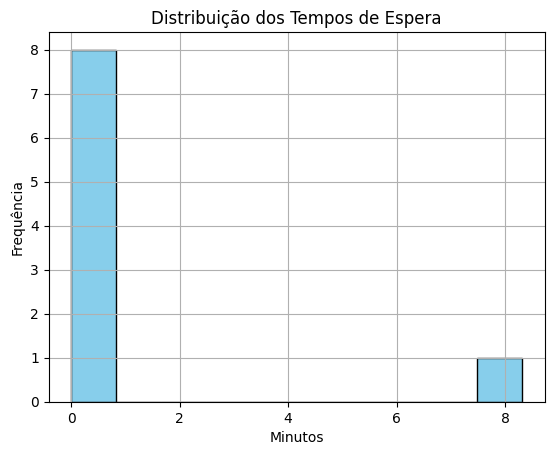

In [2]:
import simpy
import random
import matplotlib.pyplot as plt

TEMPO_SIMULACAO = 120  # minutos
TEMPO_ATENDIMENTO = 15  # minutos
CHEGADAS_POR_HORA = 4  # média de caminhões/hora

chegadas = []
esperas = []

def caminhão(env, nome, docas):
    chegada = env.now
    chegadas.append(chegada)
    print(f"{nome} chegou às {chegada:.2f}")

    with docas.request() as req:
        yield req
        espera = env.now - chegada
        esperas.append(espera)
        print(f"{nome} começou a carregar após {espera:.2f} minutos de espera")
        yield env.timeout(TEMPO_ATENDIMENTO)
        print(f"{nome} terminou às {env.now:.2f}")

def chegada_caminhoes(env, docas):
    i = 0
    while True:
        yield env.timeout(random.expovariate(CHEGADAS_POR_HORA / 60))
        i += 1
        env.process(caminhão(env, f'Caminhão {i}', docas))

env = simpy.Environment()
docas = simpy.Resource(env, capacity=2)
env.process(chegada_caminhoes(env, docas))
env.run(until=TEMPO_SIMULACAO)

# Análise gráfica
plt.hist(esperas, bins=10, color='skyblue', edgecolor='black')
plt.title("Distribuição dos Tempos de Espera")
plt.xlabel("Minutos")
plt.ylabel("Frequência")
plt.grid(True)
plt.show()


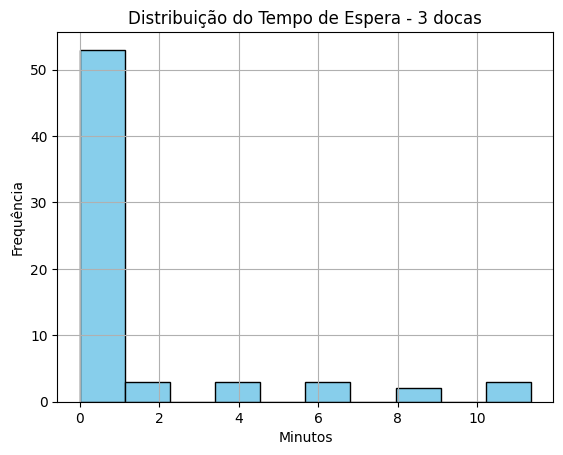

Tempo médio de espera: 1.31 minutos
Número de caminhões atendidos: 67


In [ ]:
import simpy
import random
import matplotlib.pyplot as plt

TEMPO_SIMULACAO = 500
TEMPO_ATENDIMENTO = 15
TAXA_CHEGADA = 10  # caminhões por hora

esperas = []

def caminhão(env, nome, docas):
    chegada = env.now
    with docas.request() as req:
        yield req
        espera = env.now - chegada
        esperas.append(espera)
        yield env.timeout(TEMPO_ATENDIMENTO)

def chegada_caminhoes(env, docas):
    i = 0
    while True:
        yield env.timeout(random.expovariate(TAXA_CHEGADA / 60))
        i += 1
        env.process(caminhão(env, f'Caminhão {i}', docas))

def simular(capacidade_docas=2):
    global esperas
    esperas = []
    env = simpy.Environment()
    docas = simpy.Resource(env, capacity=capacidade_docas)
    env.process(chegada_caminhoes(env, docas))
    env.run(until=TEMPO_SIMULACAO)

    plt.hist(esperas, bins=10, color='skyblue', edgecolor='black')
    plt.title(f"Distribuição do Tempo de Espera - {capacidade_docas} docas")
    plt.xlabel("Minutos")
    plt.ylabel("Frequência")
    plt.grid(True)
    plt.show()

    print(f"Tempo médio de espera: {sum(esperas)/len(esperas):.2f} minutos")
    print(f"Número de caminhões atendidos: {len(esperas)}")

# Simular para 3 docas, por exemplo:
simular(capacidade_docas=3)


In [ ]:
import simpy
import random
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

def simular_fila(capacidade_docas, taxa_chegada, tempo_servico, tempo_total):
    random.seed(42)
    esperas = []

    def caminhão(env, nome, docas):
        chegada = env.now
        with docas.request() as req:
            yield req
            espera = env.now - chegada
            esperas.append(espera)
            yield env.timeout(tempo_servico)

    def chegada_caminhoes(env, docas):
        i = 0
        while True:
            yield env.timeout(random.expovariate(taxa_chegada / 60))
            i += 1
            env.process(caminhão(env, f'Caminhão {i}', docas))

    env = simpy.Environment()
    docas = simpy.Resource(env, capacity=capacidade_docas)
    env.process(chegada_caminhoes(env, docas))
    env.run(until=tempo_total)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.hist(esperas, bins=15, color='lightblue', edgecolor='black')
    plt.title(f"Distribuição do Tempo de Espera\n{capacidade_docas} docas, chegada {taxa_chegada}/h, serviço {tempo_servico} min")
    plt.xlabel("Minutos de espera")
    plt.ylabel("Frequência")
    plt.grid(True)
    plt.show()

    print(f"Tempo médio de espera: {sum(esperas)/len(esperas):.2f} min")
    print(f"Número total de caminhões atendidos: {len(esperas)}")

"""interact(
    simular_fila,
    capacidade_docas=IntSlider(min=1, max=5, step=1, value=2, description='Docas'),
    taxa_chegada=IntSlider(min=2, max=20, step=1, value=5, description='Chegadas/h'),
    tempo_servico=IntSlider(min=5, max=30, step=1, value=15, description='Serviço (min)'),
    tempo_total=IntSlider(min=60, max=480, step=30, value=240, description='Tempo Sim. (min)')
)"""


"interact(\n    simular_fila,\n    capacidade_docas=IntSlider(min=1, max=5, step=1, value=2, description='Docas'),\n    taxa_chegada=IntSlider(min=2, max=20, step=1, value=5, description='Chegadas/h'),\n    tempo_servico=IntSlider(min=5, max=30, step=1, value=15, description='Serviço (min)'),\n    tempo_total=IntSlider(min=60, max=480, step=30, value=240, description='Tempo Sim. (min)')\n)"

In [3]:
def calcular_imc(peso, altura):
    """
    Calcula o Índice de Massa Corporal (IMC).
    peso: peso em quilogramas (kg)
    altura: altura em metros (m)
    """
    if altura <= 0:
        return "Altura inválida. A altura deve ser maior que zero."
    imc = peso / (altura ** 2)
    return imc

# Solicita ao usuário o peso e a altura
try:
    peso = float(input("Digite seu peso em kg (ex: 70.5): "))
    altura = float(input("Digite sua altura em metros (ex: 1.75): "))

    imc = calcular_imc(peso, altura)

    if isinstance(imc, str):
        print(imc)
    else:
        print(f"Seu IMC é: {imc:.2f}")

        # Classificação do IMC
        if imc < 18.5:
            print("Classificação: Abaixo do peso")
        elif 18.5 <= imc < 24.9:
            print("Classificação: Peso normal")
        elif 25 <= imc < 29.9:
            print("Classificação: Sobrepeso")
        elif 30 <= imc < 34.9:
            print("Classificação: Obesidade Grau I")
        elif 35 <= imc < 39.9:
            print("Classificação: Obesidade Grau II (severa)")
        else:
            print("Classificação: Obesidade Grau III (mórbida)")
except ValueError:
    print("Entrada inválida. Por favor, digite números para peso e altura.")


Digite seu peso em kg (ex: 70.5): 50
Digite sua altura em metros (ex: 1.75): 1.65
Seu IMC é: 18.37
Classificação: Abaixo do peso
